# Ejercicio 1 — Regresión con `beisbol.csv`

**Objetivo:** predecir las carreras anotadas (`runs`) a partir del número de bateos (`bateos`).

**Algoritmo elegido:** regresión polinómica con regularización Ridge. La relación entre bateos y carreras puede no ser estrictamente lineal; los términos polinómicos capturan curvatura y Ridge controla coeficientes grandes. Es una alternativa apropiada para un conjunto pequeño (30 equipos), porque permite ajustar complejidad mediante validación cruzada y evita usar un modelo de alta varianza.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import *
sns.set_theme(style='whitegrid', palette='viridis')
RANDOM_STATE = 42
BASE = Path.cwd()
(BASE/'images').mkdir(exist_ok=True)
(BASE/'models').mkdir(exist_ok=True)

In [2]:
df = pd.read_csv("beisbol.csv").drop(columns=['Unnamed: 0'], errors='ignore')
display(df.head())
print('Dimensiones:', df.shape)
display(df.describe(include='all'))
print('Valores faltantes:', df.isna().sum().sum())

,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


Dimensiones: (30, 3)


,equipos,bateos,runs
count,30,30.000000,30.000000
unique,29,NaN,NaN
top,Chicago,NaN,NaN
freq,2,NaN,NaN
mean,NaN,5523.500000,693.600000
std,NaN,79.873067,82.479088
min,NaN,5417.000000,556.000000
25%,NaN,5448.250000,629.000000
50%,NaN,5515.500000,705.500000
75%,NaN,5575.000000,734.000000


Valores faltantes: 0


## Diseño del modelo

1. Se elimina la columna índice sin valor predictivo.
2. Se conserva `bateos` como variable explicativa y `runs` como objetivo. `equipos` identifica observaciones, pero no se utiliza para evitar memorizar nombres.
3. Se separa 80 % para entrenamiento y 20 % para prueba.
4. El pipeline crea términos polinómicos, estandariza y aplica Ridge.
5. `GridSearchCV` busca grado y regularización con validación cruzada de 5 particiones, optimizando RMSE.

In [3]:
X = df[['bateos']]
y = df['runs']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, random_state=RANDOM_STATE)
pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scale', StandardScaler()),
    ('model', __import__('sklearn.linear_model').linear_model.Ridge())
])
grid = {'poly__degree':[1,2,3], 'model__alpha':[0.01,0.1,1,10,100]}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(pipe, grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1, return_train_score=True)
search.fit(X_train, y_train)
model = search.best_estimator_
pred = model.predict(X_test)
print('Mejores hiperparámetros:', search.best_params_)
print('RMSE CV:', round(-search.best_score_, 3))
print('MAE prueba:', round(mean_absolute_error(y_test,pred),3))
print('RMSE prueba:', round(mean_squared_error(y_test,pred)**0.5,3))
print('R² prueba:', round(r2_score(y_test,pred),3))
joblib.dump(model, BASE/'models'/'modelo_regresion_beisbol.joblib')

Mejores hiperparámetros: {'model__alpha': 1, 'poly__degree': 3}
RMSE CV: 63.397
MAE prueba: 51.583
RMSE prueba: 71.969
R² prueba: -0.506


['C:\\Python_datos\\Evaluacion SA\\Ejercicio_1_Regresion\\models\\modelo_regresion_beisbol.joblib']

## Gráfica de dispersión y comportamiento

Los puntos representan a los equipos. La curva corresponde al modelo optimizado y permite observar la tendencia estimada entre bateos y carreras.

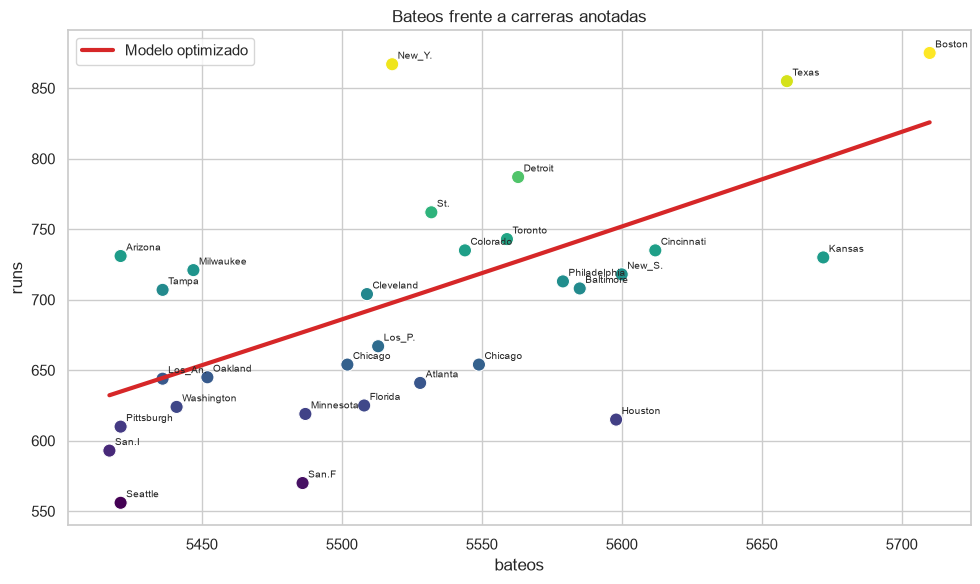

In [4]:
xx = np.linspace(X.bateos.min(), X.bateos.max(), 300).reshape(-1,1)
yy = model.predict(pd.DataFrame(xx, columns=['bateos']))
plt.figure(figsize=(10,6)); sns.scatterplot(data=df,x='bateos',y='runs',s=90,hue='runs',palette='viridis',legend=False)
plt.plot(xx,yy,color='#d62728',lw=3,label='Modelo optimizado')
for _,r in df.iterrows(): plt.annotate(r.equipos,(r.bateos,r.runs),xytext=(4,4),textcoords='offset points',fontsize=7)
plt.title('Bateos frente a carreras anotadas'); plt.legend(); plt.tight_layout(); plt.savefig(BASE/'images'/'dispersion_beisbol.png',dpi=180); plt.show()

## Valores reales contra predichos

Cuanto más cerca esté un punto de la diagonal, menor es el error. La tabla facilita revisar cada predicción del conjunto de prueba.

,Real,Predicho
equipos,,
San.F,570,676.89
Houston,615,750.57
Oakland,645,654.83
Cleveland,704,691.89
Philadelphia,713,737.96
Colorado,735,714.85


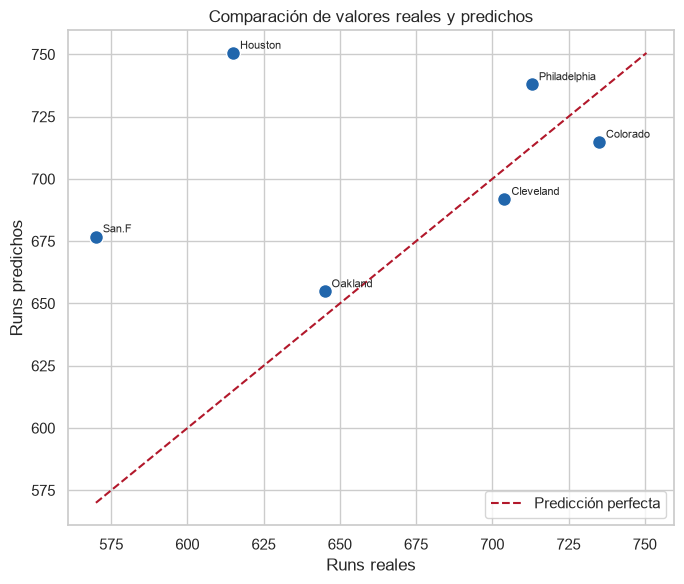

In [5]:
comp = pd.DataFrame({'Real':y_test.values,'Predicho':pred}, index=df.loc[y_test.index,'equipos']).sort_values('Real')
display(comp.round(2))
lim=[min(comp.min()),max(comp.max())]
plt.figure(figsize=(7,6)); plt.scatter(comp.Real,comp.Predicho,s=100,c='#2166ac',edgecolor='white'); plt.plot(lim,lim,'--',color='#b2182b',label='Predicción perfecta')
for equipo,r in comp.iterrows(): plt.annotate(equipo,(r.Real,r.Predicho),xytext=(5,3),textcoords='offset points',fontsize=8)
plt.xlabel('Runs reales'); plt.ylabel('Runs predichos'); plt.title('Comparación de valores reales y predichos'); plt.legend(); plt.tight_layout(); plt.savefig(BASE/'images'/'reales_vs_predichos.png',dpi=180); plt.show()

## Interpretación final

El RMSE expresa el error típico en carreras y el MAE el error absoluto promedio. R² indica qué proporción de la variabilidad se explica en el conjunto de prueba; por tratarse de solo 30 registros, debe interpretarse junto con la validación cruzada. La optimización limita la complejidad mediante el grado y `alpha`, reduciendo el riesgo de sobreajuste.